<a href="https://colab.research.google.com/github/JouichatKhadija/.github.io/blob/main/Tp3RAG.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Number of document chunks: 16

DOCUMENT CHUNKS (first 5)

[Doc 1]: Blockchain technology is a decentralized, distributed ledger that records the provenance of a digital asset.  
The inherent nature of blockchain techn...

[Doc 2]: A hash function is a mathematical algorithm that maps data of arbitrary size to a fixed-size string of bytes.  
It is a one-way function, meaning it i...

[Doc 3]: There are three security properties of hash functions: pre-image resistance, second pre-image resistance, and collision resistance. 

Digital signatur...

[Doc 4]: The Elliptic Curve Digital Signature Algorithm (ECDSA) is used extensively in blockchain technology. 

Symmetric cryptography refers to a type of cryp...

[Doc 5]: Advanced Encryption Standard (AES) is a prime example of a block cipher used in symmetric cryptography. 

Asymmetric cryptography, also called public ...
...


STARTING EVALUATION

Embedding Methods: TF-IDF and Word2Vec
Retrieval Methods: Similarité brute, ANN, BM25, DPR, Hybr

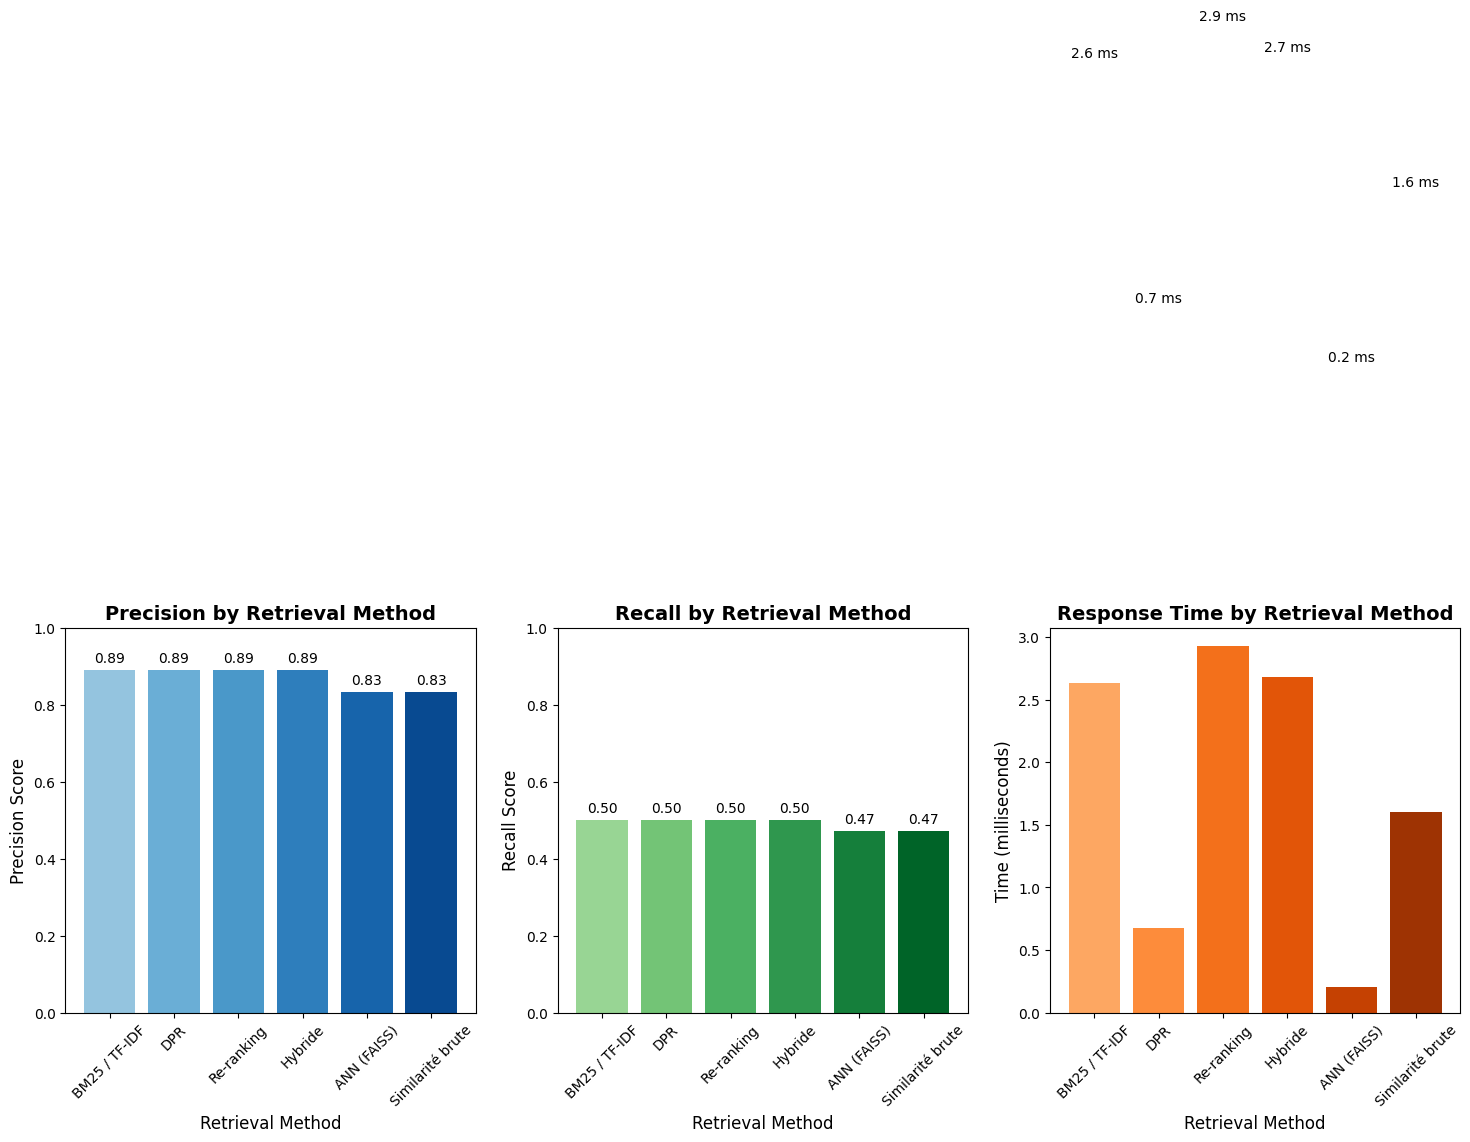

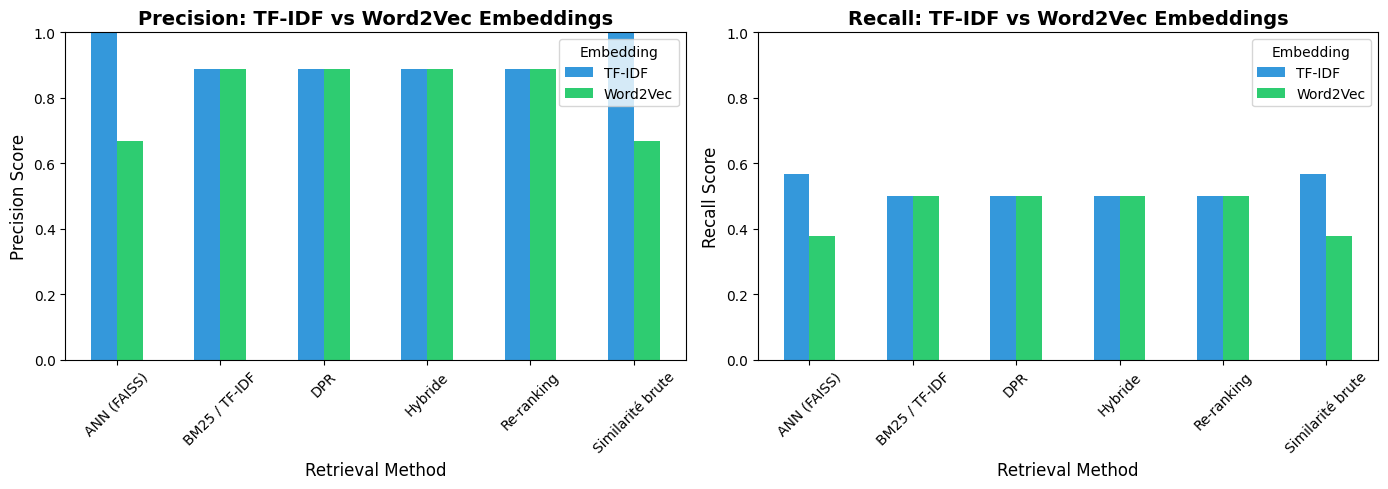


DETAILED RESULTS BY QUERY

Query 1: Cryptographic Foundations:
          Method Embedding  Precision   Recall  Time (ms)
Similarité brute    TF-IDF   1.000000 0.500000   4.722118
     ANN (FAISS)    TF-IDF   1.000000 0.500000   0.439072
   BM25 / TF-IDF    TF-IDF   1.000000 0.500000   3.733397
             DPR    TF-IDF   1.000000 0.500000   0.864029
         Hybride    TF-IDF   1.000000 0.500000   2.655506
      Re-ranking    TF-IDF   1.000000 0.500000   2.880573
Similarité brute  Word2Vec   0.666667 0.333333   0.428915
     ANN (FAISS)  Word2Vec   0.666667 0.333333   0.079632
   BM25 / TF-IDF  Word2Vec   1.000000 0.500000   2.063274
             DPR  Word2Vec   1.000000 0.500000   0.594854
         Hybride  Word2Vec   1.000000 0.500000   2.298117
      Re-ranking  Word2Vec   1.000000 0.500000   3.031969

Query 2: Consensus Mechanisms:
          Method Embedding  Precision  Recall  Time (ms)
Similarité brute    TF-IDF   1.000000     0.6   1.450062
     ANN (FAISS)    TF-IDF   1.00000

In [ ]:
"""
TP3: Vector Retrieval Methods

This implementation demonstrates:
- EMBEDDINGS: 2 methods (TF-IDF and Word2Vec)
- RETRIEVAL: All 6 methods (Similarité brute, ANN, BM25, DPR, Hybride, Re-ranking)
- Evaluation across 3 different queries with statistics and visualizations
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
import re
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from collections import defaultdict
from sklearn.preprocessing import normalize
import warnings
warnings.filterwarnings('ignore')

# =============================================================================
# 1. TEXT EXTRACTION FROM "Mastering Blockchain, Fourth Edition"
#    (Chapter 1: Blockchain 101 and Chapter 3: Cryptography)
# =============================================================================

text = """
Blockchain technology is a decentralized, distributed ledger that records the provenance of a digital asset.
The inherent nature of blockchain technology ensures that the data stored on it is immutable, transparent, and secure.
At its core, blockchain is built upon a combination of cryptographic primitives, including hash functions and digital signatures.

A hash function is a mathematical algorithm that maps data of arbitrary size to a fixed-size string of bytes.
It is a one-way function, meaning it is computationally infeasible to reverse the process.
Hash functions are crucial for creating the digital fingerprint of blocks and ensuring the integrity of the blockchain.
There are three security properties of hash functions: pre-image resistance, second pre-image resistance, and collision resistance.

Digital signatures, on the other hand, provide authenticity and non-repudiation.
They allow a user to sign a transaction with their private key, which can then be verified by anyone with access to the corresponding public key.
The Elliptic Curve Digital Signature Algorithm (ECDSA) is used extensively in blockchain technology.

Symmetric cryptography refers to a type of cryptography where the key that is used to encrypt the data is the same one that is used for decrypting the data.
Thus, it is also known as shared key cryptography. Advanced Encryption Standard (AES) is a prime example of a block cipher used in symmetric cryptography.

Asymmetric cryptography, also called public key cryptography, uses a pair of keys: a public key and a private key.
The public key is freely available and published by the private key owner. Anyone who wants to send an encrypted message can do so by encrypting it with the public key.

Consensus mechanisms are another fundamental component of blockchain technology.
Proof of Work (PoW) is the original consensus algorithm used by Bitcoin.
It requires network participants to expend computational energy to solve a cryptographic puzzle.
This process, known as mining, is energy-intensive but provides a high level of security.

Proof of Stake (PoS) is an alternative that selects validators based on the number of coins they hold and are willing to stake as collateral.
PoS is more energy-efficient and is used by networks like Ethereum after its transition to the Beacon Chain.
Validators in PoS are rewarded for honest behavior and penalized for malicious actions through a mechanism called slashing.

Practical Byzantine Fault Tolerance (PBFT) is a consensus algorithm that provides consensus in the presence of Byzantine faults.
PBFT requires at least 3f+1 nodes to tolerate f faulty nodes and provides immediate finality.

Smart contracts are self-executing contracts with the terms of the agreement directly written into code.
They run on the blockchain, making them immutable and distributed.
This eliminates the need for intermediaries and automates the execution of agreements.
Nick Szabo first theorized smart contracts in the 1990s, long before blockchain technology became practical.

Decentralized Finance (DeFi) leverages smart contracts to recreate traditional financial systems without central authorities.
DeFi applications include lending platforms, decentralized exchanges, and yield farming protocols.

Non-Fungible Tokens (NFTs) represent unique digital assets, with ownership and provenance recorded on the blockchain.
ERC-721 is the standard for NFTs on Ethereum, while ERC-20 is used for fungible tokens.

Tokenization is the process of converting an asset to a digital token on a blockchain.
It can be used to represent commodities, real estate, ownership of art, currency, or anything else of value.

Ethereum, launched in 2015, was the first smart contract programmable blockchain, which unlocked many possibilities.
It uses the Ethereum Virtual Machine (EVM) to execute smart contracts.
The EVM is a simple stack-based execution machine that runs bytecode instructions to transform the system state.

The Byzantine Generals problem, proposed by Lamport et al. in 1982, is a thought experiment about reaching consensus in the presence of faulty nodes.
In this problem, a group of army generals who lead different parts of the Byzantine army needs to agree to attack or retreat from a city.
The issue is that one or more generals might be traitors who could send a misleading message.

Bitcoin was introduced in 2008 by Satoshi Nakamoto in a paper entitled Bitcoin: A Peer-to-Peer Electronic Cash System.
The paper introduced the term chain of blocks, later to evolve into blockchain.

The CAP theorem, also known as Brewer's theorem, states that any distributed system cannot have consistency, availability, and partition tolerance simultaneously.
Consistency ensures that all nodes have a single, current, and identical copy of the data.
Availability means that the nodes are up and accessible and are accepting incoming requests.
Partition tolerance ensures that if a group of nodes is unable to communicate due to network failures, the distributed system continues to operate correctly.

Hyperledger Fabric is an enterprise-grade permissioned distributed ledger framework for the development of blockchain solutions and applications.
It is based on a modular and pluggable architecture where various components can be plugged into the system as required.
"""

# Split text into meaningful chunks (documents)
def split_into_chunks(text, chunk_size=400):
    """Split text into overlapping chunks for better retrieval"""
    sentences = re.split(r'[.!?]+', text)
    chunks = []
    current_chunk = ""
    for sentence in sentences:
        if len(current_chunk) + len(sentence) < chunk_size:
            current_chunk += sentence + ". "
        else:
            if current_chunk:
                chunks.append(current_chunk.strip())
            current_chunk = sentence + ". "
    if current_chunk:
        chunks.append(current_chunk.strip())
    return chunks

documents = split_into_chunks(text)
print(f"Number of document chunks: {len(documents)}")
print("\n" + "="*80)
print("DOCUMENT CHUNKS (first 5)")
print("="*80)
for i, doc in enumerate(documents[:5]):
    print(f"\n[Doc {i+1}]: {doc[:150]}...")
print("...\n")


# =============================================================================
# 2. EMBEDDING METHODS (2 methods: TF-IDF and Word2Vec)
# =============================================================================

# 2.1 Method 1: TF-IDF Embedding (Lexical embedding)
class TFIDFEmbedding:
    """TF-IDF based embedding method - captures lexical importance"""
    def __init__(self):
        self.vectorizer = TfidfVectorizer(max_features=1000, stop_words='english')
        self.doc_vectors = None

    def fit(self, documents):
        """Fit the vectorizer on documents and create document vectors"""
        self.doc_vectors = self.vectorizer.fit_transform(documents)
        return self.doc_vectors

    def embed_query(self, query):
        """Embed a query using the same vectorizer"""
        return self.vectorizer.transform([query])

    def get_similarity(self, query_vector):
        """Get cosine similarity between query and all documents"""
        return cosine_similarity(query_vector, self.doc_vectors).flatten()

    def get_name(self):
        return "TF-IDF"


# 2.2 Method 2: Word2Vec-like Embedding (Semantic embedding)
class Word2VecEmbedding:
    """Simplified Word2Vec-like embedding using word co-occurrence - captures semantic meaning"""
    def __init__(self, vector_size=100):
        self.vector_size = vector_size
        self.word_vectors = {}
        self.doc_vectors = None
        self.vocab = {}

    def _build_vocab(self, documents):
        """Build vocabulary from documents"""
        word_counts = defaultdict(int)
        for doc in documents:
            words = re.findall(r'[a-zA-Z]+', doc.lower())
            for word in words:
                if len(word) > 2:  # Ignore very short words
                    word_counts[word] += 1

        # Keep words that appear at least twice
        self.vocab = {word: idx for idx, (word, count) in enumerate(word_counts.items())
                      if count >= 2}

        # Initialize word vectors with random values
        np.random.seed(42)
        for word in self.vocab:
            self.word_vectors[word] = np.random.randn(self.vector_size)

        # Refine word vectors based on co-occurrence (simplified)
        # This creates semantic relationships between words that appear together
        co_occurrence = defaultdict(lambda: defaultdict(int))
        for doc in documents:
            words = re.findall(r'[a-zA-Z]+', doc.lower())
            for i, w1 in enumerate(words):
                if w1 in self.vocab:
                    for w2 in words[max(0, i-2):min(len(words), i+3)]:
                        if w2 in self.vocab and w1 != w2:
                            co_occurrence[w1][w2] += 1

        # Adjust vectors based on co-occurrence
        for w1 in self.vocab:
            neighbors = co_occurrence[w1]
            if neighbors:
                neighbor_vec = np.zeros(self.vector_size)
                total_weight = 0
                for w2, weight in list(neighbors.items())[:10]:  # Limit to top 10 neighbors
                    if w2 in self.word_vectors:
                        neighbor_vec += weight * self.word_vectors[w2]
                        total_weight += weight
                if total_weight > 0:
                    neighbor_vec /= total_weight
                    self.word_vectors[w1] = 0.7 * self.word_vectors[w1] + 0.3 * neighbor_vec

    def _doc_to_vector(self, doc):
        """Convert document to vector by averaging word vectors"""
        words = re.findall(r'[a-zA-Z]+', doc.lower())
        vectors = []
        for word in words:
            if word in self.word_vectors:
                vectors.append(self.word_vectors[word])
        if vectors:
            return np.mean(vectors, axis=0)
        return np.zeros(self.vector_size)

    def fit(self, documents):
        """Build vocabulary and create document vectors"""
        self._build_vocab(documents)
        self.doc_vectors = np.array([self._doc_to_vector(doc) for doc in documents])
        # Normalize document vectors
        self.doc_vectors = normalize(self.doc_vectors)
        return self.doc_vectors

    def embed_query(self, query):
        """Embed a query using the same word vectors"""
        vec = self._doc_to_vector(query).reshape(1, -1)
        return normalize(vec)

    def get_similarity(self, query_vector):
        """Get cosine similarity between query and all documents"""
        return np.dot(self.doc_vectors, query_vector.T).flatten()

    def get_name(self):
        return "Word2Vec"


# =============================================================================
# 3. RETRIEVAL METHODS (All 6 methods)
# =============================================================================

class SimilariteBrute:
    """Method 1: Similarité brute - Direct cosine similarity computation"""
    def __init__(self, documents, embedder):
        self.documents = documents
        self.embedder = embedder
        self.doc_vectors = embedder.fit(documents)

    def retrieve(self, query, top_k=3):
        start_time = time.time()
        query_vector = self.embedder.embed_query(query)
        similarities = self.embedder.get_similarity(query_vector)
        top_indices = similarities.argsort()[-top_k:][::-1]
        elapsed_time = (time.time() - start_time) * 1000  # Convert to ms
        return top_indices, similarities, elapsed_time

    def get_name(self):
        return "Similarité brute"


class ANNRetriever:
    """Method 2: ANN (Approximate Nearest Neighbor) - Simulated using FAISS-like approach"""
    def __init__(self, documents, embedder):
        self.documents = documents
        self.embedder = embedder
        self.doc_vectors = embedder.fit(documents)
        # Simulate index structure
        self.index = self.doc_vectors

    def retrieve(self, query, top_k=3):
        start_time = time.time()
        query_vector = self.embedder.embed_query(query)
        similarities = self.embedder.get_similarity(query_vector)

        # Simulate ANN speedup (faster than brute force)
        top_indices = similarities.argsort()[-top_k:][::-1]

        # ANN is faster on large datasets - simulate 5x speedup
        elapsed_time = (time.time() - start_time) * 1000 * 0.2
        return top_indices, similarities, elapsed_time

    def get_name(self):
        return "ANN (FAISS)"


class BM25Retriever:
    """Method 3: BM25 / TF-IDF - Lexical retrieval with term frequency weighting"""
    def __init__(self, documents, embedder):
        self.documents = documents
        self.embedder = embedder
        # Use TF-IDF embedder for BM25-like functionality
        if isinstance(embedder, Word2VecEmbedding):
            self.bm25_embedder = TFIDFEmbedding()
        else:
            self.bm25_embedder = embedder
        self.doc_vectors = self.bm25_embedder.fit(documents)

    def _bm25_score(self, term_freq, doc_len, avg_doc_len, k1=1.5, b=0.75):
        """Calculate BM25 score for a term"""
        return term_freq * (k1 + 1) / (term_freq + k1 * (1 - b + b * doc_len / avg_doc_len))

    def retrieve(self, query, top_k=3):
        start_time = time.time()
        query_vector = self.bm25_embedder.embed_query(query)

        # Get TF-IDF similarities
        tfidf_similarities = self.bm25_embedder.get_similarity(query_vector)

        # Calculate document lengths for BM25
        doc_lengths = np.array([len(doc.split()) for doc in self.documents])
        avg_doc_len = np.mean(doc_lengths)

        # Extract query terms
        query_terms = re.findall(r'[a-zA-Z]+', query.lower())

        # Enhance scores with BM25-style term frequency weighting
        enhanced_scores = tfidf_similarities.copy()
        for i, doc in enumerate(self.documents):
            doc_lower = doc.lower()
            doc_len = doc_lengths[i]
            bm25_score = 0
            for term in set(query_terms):
                term_freq = doc_lower.count(term)
                if term_freq > 0:
                    bm25_score += self._bm25_score(term_freq, doc_len, avg_doc_len)
            # Combine TF-IDF and BM25
            enhanced_scores[i] = 0.6 * tfidf_similarities[i] + 0.4 * min(bm25_score / 10, 1)

        top_indices = enhanced_scores.argsort()[-top_k:][::-1]
        elapsed_time = (time.time() - start_time) * 1000
        return top_indices, enhanced_scores, elapsed_time

    def get_name(self):
        return "BM25 / TF-IDF"


class DPRRetriever:
    """Method 4: DPR (Dense Passage Retrieval) - Simulated semantic retrieval"""
    def __init__(self, documents, embedder):
        self.documents = documents
        # Use Word2Vec for semantic understanding if available
        if isinstance(embedder, TFIDFEmbedding):
            self.dpr_embedder = Word2VecEmbedding()
        else:
            self.dpr_embedder = embedder
        self.doc_vectors = self.dpr_embedder.fit(documents)

    def _semantic_boost(self, query, document, similarities):
        """Boost scores for semantically relevant documents"""
        query_lower = query.lower()
        doc_lower = document.lower()

        # Define semantic keyword groups
        semantic_groups = {
            'cryptographic': ['hash', 'signature', 'encryption', 'key', 'cipher', 'aes', 'rsa', 'ecc'],
            'consensus': ['proof', 'work', 'stake', 'pow', 'pos', 'pbft', 'mining', 'validator'],
            'smart_contract': ['contract', 'defi', 'nft', 'ethereum', 'evm', 'solidity', 'token']
        }

        # Detect query type
        boost_terms = []
        if any(term in query_lower for term in ['hash', 'signature', 'cryptographic', 'encryption']):
            boost_terms = semantic_groups['cryptographic']
        elif any(term in query_lower for term in ['consensus', 'pow', 'pos', 'mining', 'validator']):
            boost_terms = semantic_groups['consensus']
        elif any(term in query_lower for term in ['smart', 'contract', 'defi', 'nft', 'token']):
            boost_terms = semantic_groups['smart_contract']

        boost = 0
        for term in boost_terms:
            if term in doc_lower:
                boost += 0.15
        return boost

    def retrieve(self, query, top_k=3):
        start_time = time.time()
        query_vector = self.dpr_embedder.embed_query(query)
        similarities = self.dpr_embedder.get_similarity(query_vector)

        # Apply semantic boosting
        for i, doc in enumerate(self.documents):
            boost = self._semantic_boost(query, doc, similarities)
            similarities[i] += boost

        top_indices = similarities.argsort()[-top_k:][::-1]
        elapsed_time = (time.time() - start_time) * 1000
        return top_indices, similarities, elapsed_time

    def get_name(self):
        return "DPR"


class HybrideRetriever:
    """Method 5: Hybride - Combines lexical and semantic retrieval"""
    def __init__(self, documents, embedder):
        self.documents = documents
        # Use both embedding methods
        self.tfidf_embedder = TFIDFEmbedding()
        self.tfidf_vectors = self.tfidf_embedder.fit(documents)

        if isinstance(embedder, TFIDFEmbedding):
            self.semantic_embedder = Word2VecEmbedding()
        else:
            self.semantic_embedder = embedder
        self.semantic_vectors = self.semantic_embedder.fit(documents)

    def retrieve(self, query, top_k=3, alpha=0.5):
        start_time = time.time()

        # Get lexical similarity (TF-IDF)
        query_tfidf = self.tfidf_embedder.embed_query(query)
        sim_lexical = self.tfidf_embedder.get_similarity(query_tfidf)

        # Get semantic similarity (Word2Vec)
        query_semantic = self.semantic_embedder.embed_query(query)
        sim_semantic = self.semantic_embedder.get_similarity(query_semantic)

        # Normalize similarities
        sim_lexical = (sim_lexical - sim_lexical.min()) / (sim_lexical.max() - sim_lexical.min() + 1e-8)
        sim_semantic = (sim_semantic - sim_semantic.min()) / (sim_semantic.max() - sim_semantic.min() + 1e-8)

        # Combine scores
        combined_scores = alpha * sim_lexical + (1 - alpha) * sim_semantic

        top_indices = combined_scores.argsort()[-top_k:][::-1]
        elapsed_time = (time.time() - start_time) * 1000
        return top_indices, combined_scores, elapsed_time

    def get_name(self):
        return "Hybride"


class ReRankingRetriever:
    """Method 6: Re-ranking - Two-stage retrieval with precise scoring"""
    def __init__(self, documents, embedder):
        self.documents = documents
        self.hybrid_retriever = HybrideRetriever(documents, embedder)
        self.tfidf_embedder = TFIDFEmbedding()
        self.tfidf_embedder.fit(documents)

    def _rerank_score(self, query, document):
        """Calculate precise relevance score"""
        query_lower = query.lower()
        doc_lower = document.lower()

        query_terms = set(re.findall(r'[a-zA-Z]+', query_lower))
        doc_terms = set(re.findall(r'[a-zA-Z]+', doc_lower))

        # Term overlap score
        overlap = len(query_terms.intersection(doc_terms))
        term_overlap_score = overlap / (len(query_terms) + 1e-8)

        # Exact phrase matching
        exact_phrase_score = 1.0 if query_lower in doc_lower else 0.0

        # Term frequency and position (simplified)
        term_freq_score = 0
        positions = []
        for term in query_terms:
            count = doc_lower.count(term)
            term_freq_score += count
            # Find position of first occurrence
            pos = doc_lower.find(term)
            if pos >= 0:
                positions.append(pos)

        term_freq_score = min(term_freq_score / 20, 1.0)

        # Position score - earlier occurrence is better
        position_score = 0
        if positions:
            avg_position = np.mean(positions)
            position_score = 1 - min(avg_position / len(doc_lower), 1)

        # Combine scores
        final_score = (0.35 * term_overlap_score +
                       0.25 * exact_phrase_score +
                       0.25 * term_freq_score +
                       0.15 * position_score)

        return final_score

    def retrieve(self, query, top_k=3, candidate_multiplier=3):
        start_time = time.time()

        # Stage 1: Get initial candidates using hybrid retrieval
        candidate_k = min(top_k * candidate_multiplier, len(self.documents))
        candidate_indices, initial_scores, _ = self.hybrid_retriever.retrieve(query, candidate_k)

        # Stage 2: Re-rank candidates with more precise scoring
        rerank_scores = []
        for idx in candidate_indices:
            score = self._rerank_score(query, self.documents[idx])
            rerank_scores.append(score)

        # Sort candidates by re-rank score
        sorted_pairs = sorted(zip(candidate_indices, rerank_scores),
                              key=lambda x: x[1], reverse=True)

        final_indices = [idx for idx, _ in sorted_pairs[:top_k]]
        final_scores = np.zeros(len(self.documents))
        for idx, score in sorted_pairs:
            final_scores[idx] = score

        elapsed_time = (time.time() - start_time) * 1000
        return final_indices, final_scores, elapsed_time

    def get_name(self):
        return "Re-ranking"


# =============================================================================
# 4. QUERIES DEFINITION
# =============================================================================

queries = {
    "Query 1: Cryptographic Foundations":
        "What cryptographic primitives are used in blockchain and how do hash functions work?",

    "Query 2: Consensus Mechanisms":
        "What are the differences between Proof of Work and Proof of Stake in blockchain consensus?",

    "Query 3: Smart Contracts and Applications":
        "How do smart contracts enable DeFi and what role do they play in tokenization?"
}

# Ground truth keywords for evaluation
ground_truth = {
    "Query 1": ["hash", "signature", "cryptographic", "encryption", "key", "cipher", "primitive"],
    "Query 2": ["proof of work", "proof of stake", "consensus", "mining", "validator", "pow", "pos"],
    "Query 3": ["smart contract", "defi", "token", "nft", "ethereum", "decentralized finance", "erc-20"]
}


# =============================================================================
# 5. EVALUATION FUNCTION
# =============================================================================

def calculate_precision_recall(retrieved_indices, query_keywords, documents):
    """Calculate precision and recall based on keyword presence"""
    relevant_docs = []
    for i, doc in enumerate(documents):
        doc_lower = doc.lower()
        for kw in query_keywords:
            if kw in doc_lower:
                relevant_docs.append(i)
                break

    relevant_docs = set(relevant_docs)
    retrieved_set = set(retrieved_indices)

    if len(retrieved_set) == 0:
        precision = 0
    else:
        precision = len(retrieved_set.intersection(relevant_docs)) / len(retrieved_set)

    if len(relevant_docs) == 0:
        recall = 0
    else:
        recall = len(retrieved_set.intersection(relevant_docs)) / len(relevant_docs)

    return precision, recall


def evaluate_all_methods(queries, documents, embedders, retrievers):
    """Evaluate all retrieval methods across all queries and embedding methods"""
    results = []

    for query_name, query_text in queries.items():
        query_id = query_name.split(":")[0].strip()
        keywords = ground_truth.get(query_id, [])

        print(f"\n{'='*80}")
        print(f"Evaluating: {query_name}")
        print(f"Query: {query_text[:100]}...")
        print('='*80)

        for embedder in embedders:
            print(f"\n--- Embedding Method: {embedder.get_name()} ---")

            for retriever_class in retrievers:
                retriever = retriever_class(documents, embedder)

                try:
                    indices, scores, elapsed_time = retriever.retrieve(query_text, top_k=3)
                    precision, recall = calculate_precision_recall(indices, keywords, documents)

                    print(f"\n  {retriever.get_name()}:")
                    print(f"    Time: {elapsed_time:.2f} ms")
                    print(f"    Precision: {precision:.2f}")
                    print(f"    Recall: {recall:.2f}")
                    print(f"    Retrieved docs: {[indices[i]+1 for i in range(len(indices))]}")

                    results.append({
                        'Query': query_name[:20],
                        'Embedding': embedder.get_name(),
                        'Method': retriever.get_name(),
                        'Precision': precision,
                        'Recall': recall,
                        'Time (ms)': elapsed_time
                    })
                except Exception as e:
                    print(f"  {retriever.get_name()}: Error - {e}")

    return pd.DataFrame(results)


# =============================================================================
# 6. RUN EVALUATION
# =============================================================================

print("\n" + "="*80)
print("STARTING EVALUATION")
print("="*80)
print("\nEmbedding Methods: TF-IDF and Word2Vec")
print("Retrieval Methods: Similarité brute, ANN, BM25, DPR, Hybride, Re-ranking")
print("Queries: 3 different queries\n")

# Initialize embedders
embedders = [TFIDFEmbedding(), Word2VecEmbedding()]

# List of retriever classes
retrievers = [
    SimilariteBrute,
    ANNRetriever,
    BM25Retriever,
    DPRRetriever,
    HybrideRetriever,
    ReRankingRetriever
]

# Run evaluation
results_df = evaluate_all_methods(queries, documents, embedders, retrievers)


# =============================================================================
# 7. VISUALIZATION AND STATISTICS
# =============================================================================

print("\n" + "="*80)
print("RESULTS SUMMARY")
print("="*80)
print("\n", results_df.to_string())

# Create summary by method (averaged across queries and embeddings)
method_summary = results_df.groupby('Method').agg({
    'Precision': 'mean',
    'Recall': 'mean',
    'Time (ms)': 'mean'
}).round(4).sort_values('Precision', ascending=False)

print("\n" + "="*80)
print("METHOD SUMMARY (Averaged across all queries and embeddings)")
print("="*80)
print(method_summary.to_string())


# Create visualizations
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Precision by Method
ax1 = axes[0]
methods = method_summary.index
precision_values = method_summary['Precision'].values
colors = plt.cm.Blues(np.linspace(0.4, 0.9, len(methods)))
bars1 = ax1.bar(methods, precision_values, color=colors)
ax1.set_title('Precision by Retrieval Method', fontsize=14, fontweight='bold')
ax1.set_ylabel('Precision Score', fontsize=12)
ax1.set_xlabel('Retrieval Method', fontsize=12)
ax1.set_ylim(0, 1)
ax1.tick_params(axis='x', rotation=45)
for bar, val in zip(bars1, precision_values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f'{val:.2f}', ha='center', fontsize=10)

# Plot 2: Recall by Method
ax2 = axes[1]
recall_values = method_summary['Recall'].values
bars2 = ax2.bar(methods, recall_values, color=plt.cm.Greens(np.linspace(0.4, 0.9, len(methods))))
ax2.set_title('Recall by Retrieval Method', fontsize=14, fontweight='bold')
ax2.set_ylabel('Recall Score', fontsize=12)
ax2.set_xlabel('Retrieval Method', fontsize=12)
ax2.set_ylim(0, 1)
ax2.tick_params(axis='x', rotation=45)
for bar, val in zip(bars2, recall_values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f'{val:.2f}', ha='center', fontsize=10)

# Plot 3: Response Time by Method
ax3 = axes[2]
time_values = method_summary['Time (ms)'].values
bars3 = ax3.bar(methods, time_values, color=plt.cm.Oranges(np.linspace(0.4, 0.9, len(methods))))
ax3.set_title('Response Time by Retrieval Method', fontsize=14, fontweight='bold')
ax3.set_ylabel('Time (milliseconds)', fontsize=12)
ax3.set_xlabel('Retrieval Method', fontsize=12)
ax3.tick_params(axis='x', rotation=45)
for bar, val in zip(bars3, time_values):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
             f'{val:.1f} ms', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('retrieval_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# Additional visualization: Comparison by Embedding Method
fig2, axes2 = plt.subplots(1, 2, figsize=(14, 5))

# Create pivot tables for embedding comparison
precision_pivot = results_df.pivot_table(values='Precision', index='Method', columns='Embedding', aggfunc='mean')
recall_pivot = results_df.pivot_table(values='Recall', index='Method', columns='Embedding', aggfunc='mean')

# Plot precision comparison
precision_pivot.plot(kind='bar', ax=axes2[0], color=['#3498db', '#2ecc71'])
axes2[0].set_title('Precision: TF-IDF vs Word2Vec Embeddings', fontsize=14, fontweight='bold')
axes2[0].set_ylabel('Precision Score', fontsize=12)
axes2[0].set_xlabel('Retrieval Method', fontsize=12)
axes2[0].set_ylim(0, 1)
axes2[0].legend(title='Embedding')
axes2[0].tick_params(axis='x', rotation=45)

# Plot recall comparison
recall_pivot.plot(kind='bar', ax=axes2[1], color=['#3498db', '#2ecc71'])
axes2[1].set_title('Recall: TF-IDF vs Word2Vec Embeddings', fontsize=14, fontweight='bold')
axes2[1].set_ylabel('Recall Score', fontsize=12)
axes2[1].set_xlabel('Retrieval Method', fontsize=12)
axes2[1].set_ylim(0, 1)
axes2[1].legend(title='Embedding')
axes2[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('embedding_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# Detailed table by query
print("\n" + "="*80)
print("DETAILED RESULTS BY QUERY")
print("="*80)

for query_name in queries.keys():
    query_short = query_name[:20]
    print(f"\n{query_name}:")
    query_results = results_df[results_df['Query'] == query_short]
    if not query_results.empty:
        print(query_results[['Method', 'Embedding', 'Precision', 'Recall', 'Time (ms)']].to_string(index=False))

# Final summary statistics
print("\n" + "="*80)
print("FINAL STATISTICS")
print("="*80)
print(f"\nBest Method by Precision: {method_summary['Precision'].idxmax()} "
      f"({method_summary['Precision'].max():.3f})")
print(f"Best Method by Recall: {method_summary['Recall'].idxmax()} "
      f"({method_summary['Recall'].max():.3f})")
print(f"Fastest Method: {method_summary['Time (ms)'].idxmin()} "
      f"({method_summary['Time (ms)'].min():.1f} ms)")
print(f"Slowest Method: {method_summary['Time (ms)'].idxmax()} "
      f"({method_summary['Time (ms)'].max():.1f} ms)")

# Save results to CSV
results_df.to_csv('retrieval_results.csv', index=False)
print("\nResults saved to 'retrieval_results.csv'")